### Algorithms for Massive Datasets Project Source Code
- Author: Andrea Colombo

In [71]:
# Kaggle setup for downloading the dataset, this has to be handled before
# running the rest of the notebook to avoid errors
import os

os.environ["KAGGLE_USERNAME"] = "x"
os.environ["KAGGLE_KEY"] = "x"

In [72]:
# Generic configuration related to the actual project implementation
# The user can change how much of the dataset is actually used during the run
# and other global variables that influence the behaviour of the notebook

# Generic Config
ENABLE_LOGGING = True
SAMPLING_PROPORTION = 0.3 # This can range from 0.0 (excluded) to 1.0
assert 0 < SAMPLING_PROPORTION <= 1, "Invalid sampling factor"
RAND_SEED = 42 # Set as None for random, used for dataset sampling

# Flajoret-Martin specific config
FM_NUM_HASHES = 16 # Number of hash function used for the FM algorithm
FM_GROUP_SIZES = 4
assert FM_NUM_HASHES % FM_GROUP_SIZES == 0
FM_PHI = 0.77351
FM_USE_KM_DERIVATION = False # Derive FN_NUM_HASHES from 2 hashes

# AMS Specific config
AMS_STORED_VARS = 21
# There are 42 distinct commented sections
assert AMS_STORED_VARS > 0 and AMS_STORED_VARS <= 42, "Invalid counter for AMS"

# Bloom Filter Specific config
BLOOM_FILTER_N_HASHES = 16
assert BLOOM_FILTER_N_HASHES > 0, "You need at least one hash for the bloom filter"
BLOOM_FILTER_N_BITS = 1000000
assert BLOOM_FILTER_N_BITS > 0, "Invalid bit count for bloom filter"

def log(s):
    if ENABLE_LOGGING == True:
        print(f"[LOG] {s}")


In [73]:
# Get the dataset using kaggle API (please check the kaggle auth cell before running
# this one)

%pip install -q kaggle
%pip install -q xxhash
!kaggle datasets download -d "benjaminawd/new-york-times-articles-comments-2020"
!unzip -o -d dataset new-york-times-articles-comments-2020.zip && rm -r new-york-times-articles-comments-2020.zip
# !ls -l dataset

Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
100% 1.95G/1.95G [00:26<00:00, 78.9MB/s]

Archive:  new-york-times-articles-comments-2020.zip
  inflating: dataset/nyt-articles-2020.csv  
  inflating: dataset/nyt-comments-2020.csv  
  inflating: dataset/nyt-comments-part0.csv  
  inflating: dataset/nyt-comments-part1.csv  
  inflating: dataset/nyt-comments-part2.csv  
  inflating: dataset/nyt-comments-part3.csv  
  inflating: dataset/nyt-comments-part4.csv  
  inflating: dataset/nyt-comments-part5.csv  
  inflating: dataset/nyt-comments-part6.csv  
  inflating: dataset/nyt-comments-part7.csv  
  inflating: dataset/nyt-comments-part8.csv  
  inflating: dataset/nyt-comments-part9.csv  
  inflating: dataset/test.csv        
  inflating: dataset/train.csv       


In [74]:
%pip install pyspark
%pip install py4j

import pyspark

log(f"PySpark Ver: {pyspark.__version__}")

spark_session = pyspark.sql.SparkSession.builder.getOrCreate()
spark_context = spark_session.sparkContext

[LOG] PySpark Ver: 4.0.4


In [75]:
df = (spark_session.read
      .option("header", "true")
      .option("inferSchema", "true")
      .option("quote", '"')
      .option("escape", '"')
      .option("multiLine", "true")
      .option("mode", "PERMISSIVE")
      .csv("dataset/nyt-comments-2020.csv")
      .sample(withReplacement=False, fraction=SAMPLING_PROPORTION, seed=RAND_SEED)
      .cache())

# df.show(5, truncate=False)
# df.printSchema()
log(f"Dataset columns {df.columns}")
# log(f"Dataset count {df.count()}")

[LOG] Dataset columns ['commentID', 'status', 'commentSequence', 'userID', 'userDisplayName', 'userLocation', 'userTitle', 'commentBody', 'createDate', 'updateDate', 'approveDate', 'recommendations', 'replyCount', 'editorsSelection', 'parentID', 'parentUserDisplayName', 'depth', 'commentType', 'trusted', 'recommendedFlag', 'permID', 'isAnonymous', 'articleID']


In [76]:
import os

# Set up user streams for partitions
# The dataset has null entries so they have to be cleaned up to avoid
# null strings giving us garbage with the hashes
users_stream = (
    df.
    select("userID").
    where("userID IS NOT NULL").
    rdd.
    map(lambda row: row["userID"])
)

# TODO: check why multiline csv parsing forces it to one partition
# just use default values (same as cpu cores?) for now
users_stream = users_stream.repartition(spark_context.defaultParallelism)
users_stream.getNumPartitions()

2

# FM Algorithm Implementation

Each userID is used to calculate _n_ hash functions (FM_NUM_HASHES). We keep track of the
maximum number of trailing zeros for each has function and we use the registers of each
partition for the final estimate

In [77]:
import xxhash
import statistics
from random import randint

def ctz(x):
    if x == 0:
        return 64
    return (x & -x).bit_length() - 1

def hash64bits(value, seed):
    return xxhash.xxh3_64(value.to_bytes(8, 'little'), seed).intdigest()

def fm_partition(it):
    registers = [0] * FM_NUM_HASHES
    for user in it:
        for i in range(FM_NUM_HASHES):
            bits = hash64bits(user, i)
            r = ctz(bits)
            if r > registers[i]:
                registers[i] = r

    yield registers


In [78]:
mapped = users_stream.mapPartitions(fm_partition)
registers = mapped.reduce(lambda a, b: [max(x, y) for x, y in zip(a, b)])

In [79]:
# Naive with no groups
estimates = [(2 ** r) / FM_PHI for r in registers]
fm_estimate = statistics.median(estimates)
print("FM estimate without grouping:", round(fm_estimate))

FM estimate without grouping: 338902


In [80]:
# Test implementation with grouping
groups = [registers[i:i+FM_GROUP_SIZES] for i in range(0, len(registers), FM_GROUP_SIZES)]
group_means = [sum(g)/len(g) for g in groups]
group_estimates = [(2**m)/FM_PHI for m in group_means]
estimate = statistics.median(group_estimates)
print("FM estimate with grouping", round(estimate))

FM estimate with grouping 262311


In [81]:
# For error calculation
actual = df.select("userID").distinct().count()
print("Correct result: ", actual)

# Compare with HLL to see how worse it is
from pyspark.sql.functions import approx_count_distinct
print(f"HyperLogLog estimate {df.select(approx_count_distinct("userID")).collect()}")

Correct result:  218567
HyperLogLog estimate [Row(approx_count_distinct(userID)=238510)]


# AMS Algorithm Implementation

In [82]:
import pyspark.sql.functions as F

articles = (spark_session.read
            .option("header", "true")
            .option("inferSchema", "true")
            .option("quote", '"')
            .option("escape", '"')
            .option("multiLine", "true")
            .csv("dataset/nyt-articles-2020.csv"))

# The sampling is already done based on the FM dataframe, no need for additional
# things here
commented_sections = (df
                      .select("articleID")
                      .join(articles.select(
                           F.col("uniqueID").alias("articleID"), "section"),
                               on="articleID", how="inner")
                       .select("section")
                       .cache())

In [83]:
# estimate the second moment of the commented sections

frequencies = (commented_sections
               .groupBy("section")
               .count()
               .orderBy(F.col("count").desc()))

# frequencies.show(42)

row = frequencies.select(
    F.sum(F.pow(F.col("count"), 2)).alias("F2"),
    F.sum("count").alias("n"),
    F.count("*").alias("distinct_sections")
).collect()[0]

n, F2, k = row["n"], row["F2"], row["distinct_sections"]
print(f"n  = {n:,}")
print(f"F2 = {F2:,.0f}")
print(f"uniform-case F2 = {n*n/k:,.0f}")
print(f"skew ratio = {F2/(n*n/k):.2f}x")

n  = 1,498,190
F2 = 533,168,431,742
uniform-case F2 = 53,442,220,860
skew ratio = 9.98x


In [84]:
def ams_stream_counters(it, stored_vars=AMS_STORED_VARS, eval_every=None):
    import random
    rng = random.Random(RAND_SEED)
    stored = [] # variables
    counters = [] # counters for variables
    n = 0
    filling_reservoir = True
    for element in it:
        n += 1
        if len(counters) < stored_vars:
            # The first k elements (k = number of variables to store) are
            # added directly with count = 1
            stored.append(element)
            counters.append(1)
        else:
            # Done setting up reservoir, enable eviction
            # policy
            filling_reservoir = False

        for i in range(len(counters)):
            if filling_reservoir and i == len(counters) - 1:
                continue # avoid bug that starts variables to count 2
            if rng.random() < 1 / n and not filling_reservoir:
                stored[i] = element
                counters[i] = 1
            elif element == stored[i]:
                counters[i] += 1

        # yield everu x iterations for infinite streams to have
        # running parameter to watch
        if eval_every is not None and n % eval_every == 0:
            yield n, counters

    yield n, counters

result = ams_stream_counters(commented_sections.rdd.toLocalIterator(), 30)
n, counters = next(result)

estimates = [n * (2 * c - 1) for c in counters]
f2_test = sum(estimates) / len(estimates)
# print(counters)
print(f2_test)

636535885420.6666


In [85]:
print(f"Error compared to the correct answer: {abs((F2 - f2_test) / F2 * 100)}%")

Error compared to the correct answer: 19.387391961849325%


# Bloom Filter Implementation
Given the articles of a specific section, we want to check whether an user has already commented an article of that specific session before

In [86]:
class BloomFilter:
    def __init__(self, num_hashes=BLOOM_FILTER_N_HASHES, nbits=BLOOM_FILTER_N_BITS):
        assert num_hashes > 0, "invalid num of hashes"
        assert nbits > 0, "invalid num of bits"
        self.nbits = nbits
        self.n_hashes = num_hashes
        self.bits = 0 # Python's ints are not size bounded
        self.size = 0 # Num of times we called self.add
        self.hash_fns = [
            lambda x, seed=i: xxhash.xxh3_64(x.to_bytes(8, "little"), seed=seed).intdigest()
            for i in range(num_hashes)
        ]

    def add(self, x):
        self.bits |= self._map_bits(x)
        self.size += 1

    def _map_bits(self, x):
        mask = 0
        for hf in self.hash_fns:
            mask |= (1 << (hf(x) % self.nbits))
        return mask

    def contains(self, x):
        xmask = self._map_bits(x)
        return (self.bits & xmask) == xmask


In [87]:
# Prepare most commented section for testing. In order to properly test
# the bloom filter we want the biggest stream possible
most_commented = (commented_sections.
                  groupBy("section").
                  count().
                  orderBy(F.desc("count")).
                  first())

log(f"Most commented section = {most_commented["section"]}")
log(f"Number of comments = {most_commented["count"]}")

articles_of_section = (spark_session.read
                       .option("header", "true")
                       .option("inferSchema", "true")
                       .option("quote", '"')
                       .option("escape", '"')
                       .option("multiLine", "true")
                       .option("mode", "PERMISSIVE")
                       .csv("dataset/nyt-articles-2020.csv")
                       .sample(withReplacement=False, fraction=SAMPLING_PROPORTION, seed=RAND_SEED).
                       filter(F.col("section") == most_commented["section"]).
                       select("uniqueID").
                       cache())

# articles_of_section.show(5, truncate=False)

commentors = (df
              .join(articles_of_section, df["articleID"] == articles_of_section["uniqueID"], "inner")
              .select(df["userID"])
              .rdd
              .map(lambda row: row["userID"])
              .toLocalIterator())

# for i in range(5):
#     print(next(commentors))

[LOG] Most commented section = Opinion
[LOG] Number of comments = 624458


test with 1000000 bits and 16 hash:   0%|          | 0/194673 [00:00<?, ?it/s]

[TEST DEFAULT] Correct count = 55444, false positives = 2


Running configs for BF testing:   0%|          | 0/60 [00:00<?, ?it/s]

test with 2996380 bits and 1 hash:   0%|          | 0/194673 [00:00<?, ?it/s]

test with 2996380 bits and 2 hash:   0%|          | 0/194673 [00:00<?, ?it/s]

...

test with 17978280 bits and 6 hash:   0%|          | 0/194673 [00:00<?, ?it/s]

test with 17978280 bits and 7 hash:   0%|          | 0/194673 [00:00<?, ?it/s]

test with 17978280 bits and 8 hash:   0%|          | 0/194673 [00:00<?, ?it/s]

test with 17978280 bits and 9 hash:   0%|          | 0/194673 [00:00<?, ?it/s]

test with 17978280 bits and 10 hash:   0%|          | 0/194673 [00:00<?, ?it/s]

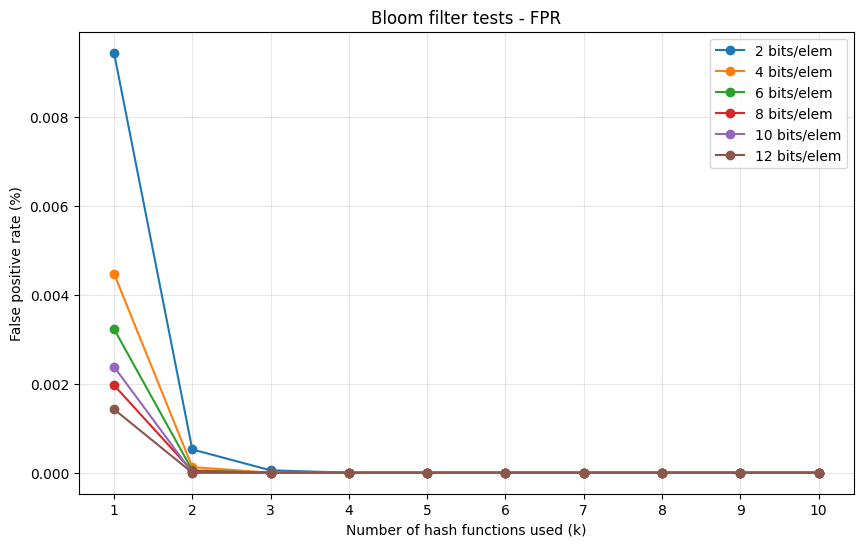

In [88]:
from tqdm.auto import tqdm

def test_bf(bf, it):
    seen = set()
    false_positives = 0
    queries = 0
    # for e in tqdm(it, f"test with {bf.nbits} bits and {bf.n_hashes} hash"):
    for e in it:
        if e not in seen:
            queries += 1
            if bf.contains(e):
                false_positives += 1
        seen.add(e)
        bf.add(e)
    return len(seen), queries, false_positives

# quick test with chosen params
users_filter = BloomFilter()
commentors_duped = list(commentors) # needed for test runs below
correct, q, false_positives = test_bf(users_filter, commentors_duped)
print(f"[TEST DEFAULT] Correct count = {correct}, false positives = {false_positives}")

# evaluate multiple configs
#
# WARNING: this takes quite a lot of time to run
#
bits_per_elem = [2, 4, 6, 8, 10, 12]
nhashes = range(1, 11)
configs = [(bpe, k) for bpe in bits_per_elem for k in nhashes]
results = []

for bpe, k in tqdm(configs, "Running configs for BF testing"):
    m = bpe * n
    bf = BloomFilter(num_hashes=k, nbits=m)
    _, queries, false_pos = test_bf(bf, commentors_duped)
    results.append({
        "bpe": bpe,
        "m": m,
        "k": k,
        "queries": queries,
        "fpos": false_pos,
        "fpr": false_pos / queries
    })

import pandas as pd

results_df = pd.DataFrame(results)
results_df.head()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

for bpe in bits_per_elem:
    data = results_df[results_df["bpe"] == bpe]
    plt.plot(data["k"], data["fpr"], marker="o", label=f"{bpe} bits/elem")

plt.xlabel("Number of hash functions used (k)")
plt.ylabel("False positive rate (%)")
plt.title("Bloom filter tests - FPR")
plt.xticks(list(nhashes))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [89]:
for r in results:
    print(r["fpr"])

0.009432941346223217
0.0005230502849722243
5.410865016954044e-05
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.004472981747348676
0.000126253517062261
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.003228482793449246
5.410865016954044e-05
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0019659476228266358
3.607243344636029e-05
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0023807806074597794
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0014248611211312315
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
